Question 6.1 : FITS file analysis

Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   

SIMPLE    = True
BITPIX    = 16
NAXIS     = 2
NAXIS1    = 530
NAXIS2    = 530

The shape of the array: (530, 530)

The dtype of the data: >i2
N=280900 min=1507, max=15752, mean=4795.924268422927, std=1848.2558984219054
3551 876
Mode of the data: 3551 with 876 counts
Median of the data: 4102.0




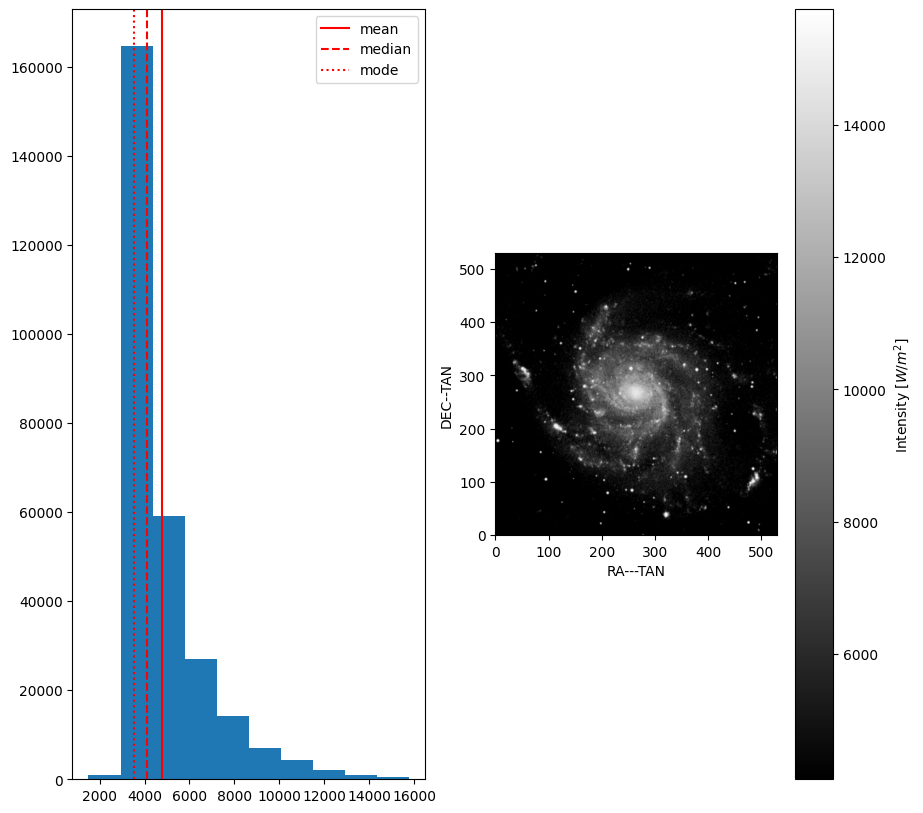

Filename: m101_float.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (280900,)   int16   

SIMPLE    = True
BITPIX    = 16
NAXIS     = 1
NAXIS1    = 280900
EXTEND    = True



In [5]:
from astropy.io import fits
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# open the file
file = fits.open('m101.fits')
file.info()
print()

#There are two HDUs
#primary HDU contains the image data [0]
#number type of the image data: PrimaryHDU

hdr = file[0].header # reads the keywords of the header
for key in hdr[:5]:
    print(f"{key:10s}= {hdr[key]}")
print()

#BITPIX=16 - since PrimaryHDU is stored in 16 bit integers, it corresponds

dat = file[0].data

print(f"The shape of the array: {np.shape(dat)}")
print()
# This corresponds to the values NAXIS1 and NAXIS2 returned by info()

print(f"The dtype of the data: {dat.dtype}") # this is code for int16 in BITPIX

flatdat = dat.flatten()

nobs, (minval, maxval), mean, var, skew, kurt = stats.describe(dat.flat)
print(f"N={nobs} min={minval}, max={maxval}, mean={mean}, std={var**0.5}")

mode, counts = stats.mode(dat.flat)
print(mode, counts)
print(f"Mode of the data: {mode} with {counts} counts")

median = np.median(dat.flat)
print(f"Median of the data: {median}")
print()

fig = plt.figure(figsize = (10,10))
frame = fig.add_subplot(1,2,1)
frame.hist(flatdat)

frame.axvline(x = mean, label = "mean", color ='red')
frame.axvline(x = median, label = "median",color = 'red', linestyle = '--')
frame.axvline(x = mode, label = "mode", color = 'red', linestyle = ':')

plt.legend()
#plt.show()

imgdat = np.asarray(flatdat)
datsort = np.sort(imgdat) # sorting the array to find the median
median2 = (datsort[len(datsort)//2]+datsort[len(datsort)-(len(datsort)//2)])/2 # calculating the average of the two central elements
print()
frame2 = fig.add_subplot(1,2,2)
pic = frame2.imshow(dat,origin="lower", cmap='gray', vmin=median2)
fig.colorbar(pic, label = r"Intensity $[W/m^2]$")
frame2.set_xlabel(hdr['CTYPE1'])
frame2.set_ylabel(hdr['CTYPE2'])
plt.show()


hdr['BUNIT'] = 'Counts'

for i in range(len(flatdat)):
    flatdat[i] = float(flatdat[i])

flatdat.shape[530:530]
    
newdata = np.array(flatdat)

newfile = fits.PrimaryHDU(flatdat)
newfile.header = hdr    # we copy the old header
newfile.writeto('m101_float.fits', overwrite=True, output_verify='ignore')

#checking the contents of the new file:
newfile = fits.open('m101_float.fits')
newfile.info()
print()


hdr = newfile[0].header # reads the keywords of the header
for key in hdr[:5]:
    print(f"{key:10s}= {hdr[key]}")
print()

Question 6.3 : Properties of a signal free area in an image

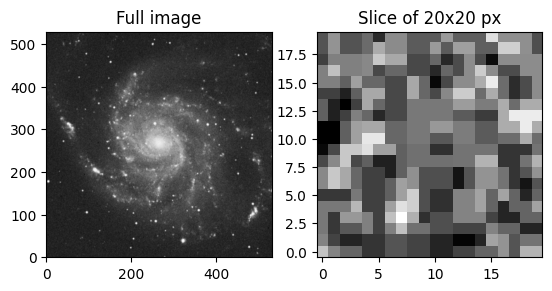

The root mean square of the slice: 3375.742901569964
The mean: 3364.8075, the standard deviation: 271.4970081672172


In [48]:
from astropy.io import fits
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt

# open the file
file = fits.open('m101.fits')
dat = file[0].data

noisebg = dat[0:20,20:40]

fig = plt.figure()
frame1 = fig.add_subplot(1,2,1)
frame1.set_title('Full image')
plt.imshow(dat, cmap = 'gray', origin="lower")
frame2 = fig.add_subplot(1,2,2)
frame2.set_title('Slice of 20x20 px')
plt.imshow(noisebg, cmap = 'gray', origin="lower")
plt.show()

flatbg = noisebg.flatten()

rms = sqrt(1/(len(flatbg))*np.sum((flatbg)**2.))

print(f"The root mean square of the slice: {rms}")
print(f"The mean: {float(np.mean(flatbg))}, the standard deviation: {float(np.std(flatbg))}")

#The RMS is the mean deviation of the values from zero, while standard deviation is the deviation from the mean
# The standard deviation gives a better estimate of the noise because the mean is the sky brightness, which is not 0
# The variation in sky brightness is the noise, which is then quantified by the standard deviation

Question 6.5 : Image stack and noise reduction

The standard deviation of the first map: 9.98401556679484
The standard deviation of the second map: 10.003955116338458
The standard deviation of the third map: 9.995349488722516


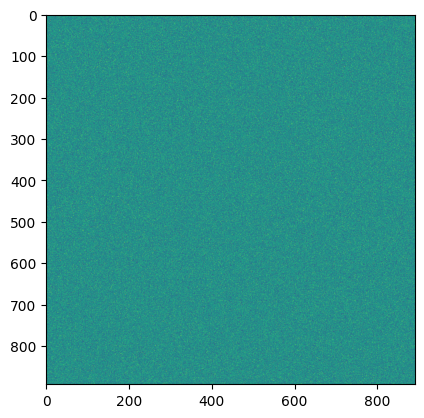

The standard deviation in the mean image: 5.773
The standard deviation from the individual variances of the three noise maps: 5.770
The difference between the two values is: 0.003


In [83]:
from astropy.io import fits
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt

file0 = fits.open('noisemap0.fits')
nmap0 = file0[0].data

std0 = np.std(nmap0)
print(f"The standard deviation of the first map: {std0}")

file1 = fits.open('noisemap1.fits')
nmap1 = file1[0].data

std1 = np.std(nmap1)
print(f"The standard deviation of the second map: {std1}")

file2 = fits.open('noisemap2.fits')
nmap2 = file2[0].data

std2 = np.std(nmap2)
print(f"The standard deviation of the third map: {std2}")


#stacking the arrays:

stacknoise = np.stack((nmap0,nmap1,nmap2),axis = 0)
stackmean = np.mean(stacknoise, axis=0)

plt.imshow(stackmean)
plt.show()

stdstack = np.std(stackmean)

print(f"The standard deviation in the mean image: {stdstack:.3f}")
    
sigma = 1/len(stacknoise)*sqrt(std0**2+std1**2+std2**2)

print(f"The standard deviation from the individual variances of the three noise maps: {sigma:.3f}")
print(f"The difference between the two values is: {abs(stdstack-sigma):.3f}")

Question 6.6 : FITS Table and table modification

In [31]:
from astropy.io import fits
from astropy.table import Table
import numpy as np

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
print(colnames)



mask_starflag = (data['STARFLAG']==0) # creating masks for all columns based on the conditions provided
mask_aspcapflag = (data['ASPCAPFLAG']==0)
mask_snr = (data['SNR']>10)
mask_parallax = (data['GAIAEDR3_PARALLAX']/data['GAIAEDR3_PARALLAX_ERROR'] > 5)
mask_magG = (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG']))
mask_magBP = (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG']))
mask_magRP = (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))

mask = mask_starflag & mask_aspcapflag & mask_snr & mask_parallax & mask_magG & mask_magBP & mask_magRP # uniting all masks

dataflag = []
for i in mask:
    if i == True:
        dataflag.append(1)
    else:
        dataflag.append(0)

t = Table(data)
t['DATAFLAG'] = dataflag

print(t['DATAFLAG'])


absmag = np.where(t['DATAFLAG'] == 0, -1.0,t['GAIAEDR3_PHOT_G_MEAN_MAG']+5*np.log10((t['GAIAEDR3_PARALLAX'])/1000))

t['ABSMAG'] = absmag
print(t['ABSMAG'])

# creating the new file

t.write('APOGEE_update.fits', overwrite=True)

print("The updated table:")
print(t)

# Open the FITS file
hdul2 = fits.open('APOGEE_update.fits')

# Access the primary data (in this case, it is a Table)
data2 = hdul2[1].data  # Often, the first extension contains the table
colnames = hdul2[1].columns.names # List of the column names
print(colnames)



['GAIAEDR3_PARALLAX', 'GAIAEDR3_PARALLAX_ERROR', 'GAIAEDR3_PHOT_G_MEAN_MAG', 'GAIAEDR3_PHOT_BP_MEAN_MAG', 'GAIAEDR3_PHOT_RP_MEAN_MAG', 'ASPCAPFLAG', 'STARFLAG', 'SNR']
DATAFLAG
--------
       0
       0
       0
       0
       1
       0
       1
     ...
       0
       0
       0
       0
       0
       0
       0
Length = 733901 rows
  ABSMAG  
----------
      -1.0
      -1.0
      -1.0
      -1.0
-2.2118397
      -1.0
-2.0147276
       ...
      -1.0
      -1.0
      -1.0
      -1.0
      -1.0
      -1.0
      -1.0
Length = 733901 rows


/tmp/ipykernel_1878347/671804421.py:38: RuntimeWarning: invalid value encountered in log10
  absmag = np.where(t['DATAFLAG'] == 0, -1.0,t['GAIAEDR3_PHOT_G_MEAN_MAG']+5*np.log10((t['GAIAEDR3_PARALLAX'])/1000))


The updated table:
GAIAEDR3_PARALLAX GAIAEDR3_PARALLAX_ERROR ... DATAFLAG   ABSMAG  
----------------- ----------------------- ... -------- ----------
              nan                     nan ...        0       -1.0
       0.28544167                0.019475 ...        0       -1.0
       0.08209286                0.315081 ...        0       -1.0
        1.2985312              0.00952245 ...        0       -1.0
        1.2985312              0.00952245 ...        1 -2.2118397
      -0.02394128               0.0450072 ...        0       -1.0
        1.3863556               0.0175672 ...        1 -2.0147276
              ...                     ... ...      ...        ...
         4.132398                0.015343 ...        0       -1.0
      0.057267956               0.0597211 ...        0       -1.0
        1.4367273               0.0213831 ...        0       -1.0
       0.42296618               0.0192445 ...        0       -1.0
       0.33459017               0.0153441 ...        0   

Question 6.7 : Exploring GAIA data

42489404.0
[[1.7418337e+07 2.3584286e+02 5.0075534e-03 1.1711010e+01 4.4500018e-03
  4.2489404e+07 5.6497030e+03 6.6176990e+00 1.5722506e+07 9.9471670e+03
  7.3600955e+00 3.1655918e+07 2.0056184e+04 6.0107636e+00 0.0000000e+00
  0.0000000e+00]]


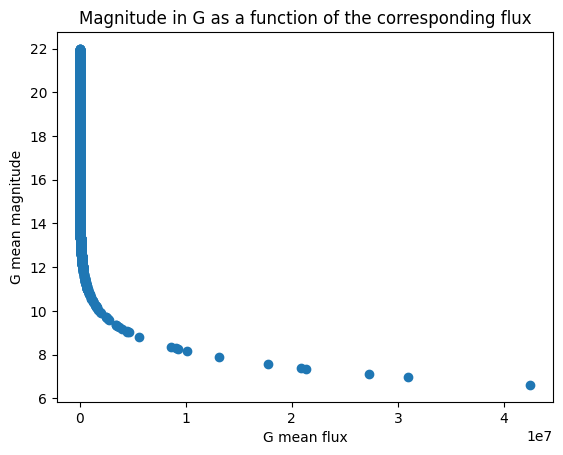

The estimate for m0 is: 25.68840037029544


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('gaiaTestData.csv') # read the csv file

dfgaia = pd.DataFrame(data) # convert to data frame

gmax = np.max(dfgaia['phot_g_mean_flux']) # finding the maximum value
print(gmax)

maxrow = np.where(dfgaia['phot_g_mean_flux'] == gmax) # finding the index of the maximum value
print(dfgaia.values[maxrow]) # printing the entire row at that index

dfsorted = dfgaia.sort_values(by='phot_g_mean_flux', ascending=True) # sorting with respect to phot_g_mean_flux

fig = plt.figure()
frame = fig.add_subplot(1,1,1)
plt.scatter(dfsorted['phot_g_mean_flux'],dfsorted['phot_g_mean_mag'])
frame.set_title('Magnitude in G as a function of the corresponding flux')
frame.set_xlabel('G mean flux')
frame.set_ylabel('G mean magnitude')
plt.show()

m0 = []
for m,F in zip(dfsorted['phot_g_mean_mag'],dfsorted['phot_g_mean_flux']):
    m0.append(m+2.5*np.log10(F))
    

m0_mean = np.mean(np.array(m0))
print(f"The estimate for m0 is: {m0_mean}")

Question 6.10 : Retrieving data using astroquery

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astroquery.gaia import Gaia
from astropy.io import fits
from astropy.table import Table


full_query = """
SELECT TOP 50
   source_id,
   ra, dec, 
   parallax, parallax_error, 
   phot_g_mean_mag, 
   phot_bp_mean_mag, 
   phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax/parallax_error > 5 
    AND phot_g_mean_mag IS NOT NULL
    AND phot_bp_mean_mag IS NOT NULL
    AND phot_rp_mean_mag IS NOT NULL
ORDER BY random_index"""

print("Sending query to Gaia archive...")
job = Gaia.launch_job(full_query)
results = job.get_results()

print(f"Retrieved {len(results)} stars")
print(f"\nResult type: {type(results)}")

gaia = results.to_pandas() # to dataframe

table = Table.from_pandas(gaia) # to table
table.write('astroquery_gaia.fits', overwrite =True) # save table

Sending query to Gaia archive...
Retrieved 50 stars

Result type: <class 'astropy.table.table.Table'>


Question 6.14 : Update your fibonacci code using OOP

In [2]:
class Fibonacci:
    """Class for calculating Fibonacci sequence"""
    def __init__(self,N,M):
        self.N = N
        self.M = M
        
    def fibo(self):
        '''
        The function lists Fibonacci numbers that meet certain requirements.
        Params: N (int), M (int)
        Return: f_m (list) containing all Fibonacci numbers smaller than N and divisible by M.
        '''
        N = self.N
        M = self.M
        
        f = [0]  # list for the Fibonacci numbers smaller than N
        f_m = [] # list for members of f divisible by M

        if M <= 0 or N <= 0:
            return "math error"

        elif 0 < N <=1: # the Fibonacci number smaller than N is zero. Zero is divisible by everything except zero.
            return f

        f.append(1) # if N > 1, 1 can be added to f

        # the next part of the code only runs if the 'if' and 'elif' conditions are not met

        t = f[-1]+f[-2] # t: the next element of the series
        while t < N: 
            f.append(t) 
            t = f[-1]+f[-2]

        for k in f:
            if k%M == 0: # deciding about each element if it is divisible by M
                f_m.append(k) # if yes, we add it to f_m
        return f_m

print(Fibonacci(100,7).fibo()) # the example values

#code should give fibonacci numbers smaller than the Nth term that are divisible by M.
# it is better to define multiple methods inside an object, so here one for f and one for f_m

[0, 21]
